### Preprocess 목적
- grayscale이 도움이 되는지
- blur가 오히려 정보를 죽이는지
- threshold가 문서 구조를 살리는지
- edge가 의미가 있는지
- 최종적으로 transforms.py에 넣을 만한지 등

In [1]:
import os
import sys
from pathlib import Path

ROOT = Path().resolve().parents[2]

os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("CWD:", Path.cwd())

ROOT: /home/jay/dev/document-type-classification-cv-2
CWD: /home/jay/dev/document-type-classification-cv-2


In [3]:
from typing import cast

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config

In [ ]:
cfg = load_config(
    base_path=ROOT / "configs/base.yaml",
    data_path=ROOT / "experiments/template/configs/data.yaml",
    train_path=ROOT / "experiments/template/configs/train.yaml",
    inference_path=ROOT / "experiments/template/configs/inference.yaml",
    model_path=ROOT / "experiments/template/configs/model.yaml",
)

print(cfg)

namespace(project=namespace(name='document-type-classification', task='multiclass-image-classification', seed=42, num_classes=17, class_names=None), paths=namespace(data_dir='data', raw_dir='data/raw', processed_dir='data/processed', split_dir='data/split', train_csv='data/raw/train.csv', test_csv='data/raw/test.csv', sample_submission_csv='data/raw/sample_submission.csv', train_image_dir='data/raw/train', test_image_dir='data/raw/test', output_dir='experiments/yoojw/outputs', checkpoint_dir='experiments/yoojw/outputs/checkpoints', log_dir='experiments/yoojw/outputs/logs', submission_dir='outputs/submissions'), runtime=namespace(device='auto', amp=True, compile=False, benchmark=False, deterministic=False), logging=namespace(use_wandb=True, wandb_project='document-type-classification', wandb_entity=None, log_interval=50, save_best_only=True, verbose=True), data=namespace(image_col='ID', label_col='target', num_workers=0, pin_memory=False, persistent_workers=False), image=namespace(size=

In [5]:
train_df = pd.read_csv(cfg.paths.train_csv)

print("shape:", train_df.shape)
train_df.head()

shape: (1570, 2)


,ID,target
0,002f99746285dfdd.jpg,16
1,008ccd231e1fea5d.jpg,10
2,008f5911bfda7695.jpg,10
3,009235e4c9c07af5.jpg,4
4,00b2f44967580c74.jpg,16


image_name: f0d11155d48758de.jpg
image_path: data/raw/train/f0d11155d48758de.jpg


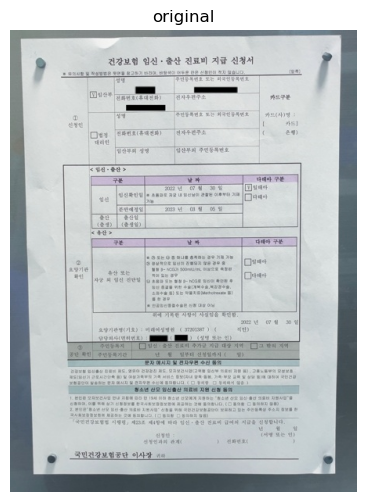

In [6]:
image_col = cfg.data.image_col

image_name = train_df[image_col].sample(1, random_state=42).iloc[0]
image_path = Path(cfg.paths.train_image_dir) / image_name

print("image_name:", image_name)
print("image_path:", image_path)

raw_image = cv2.imread(str(image_path))
if raw_image is None:
    raise ValueError(f"Failed to load image: {image_path}")

image_bgr = cast(np.ndarray, raw_image)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("original")
plt.axis("off")
plt.show()

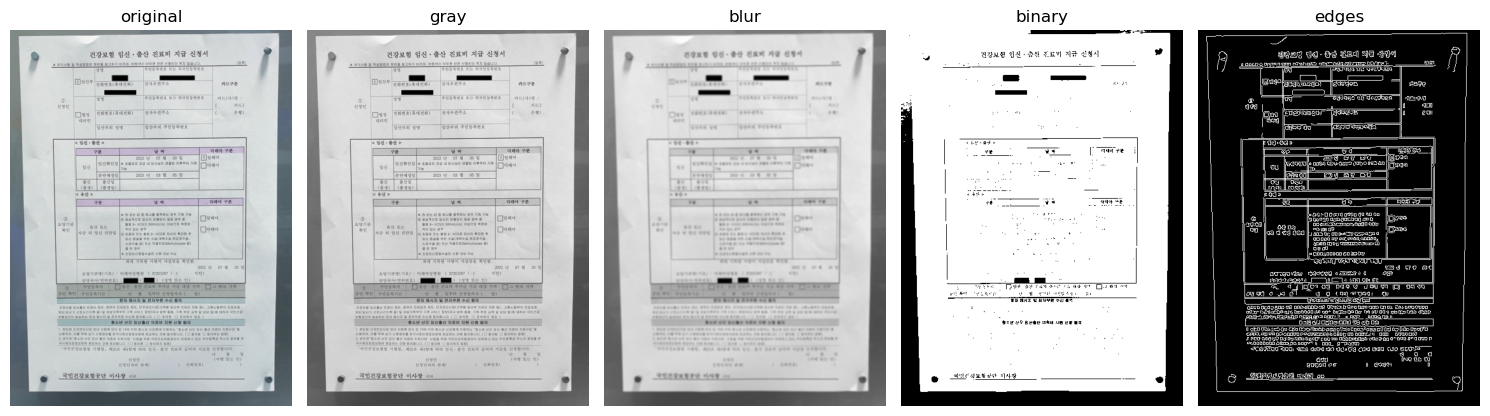

In [8]:
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(15, 8))

plt.subplot(1, 5, 1)
plt.imshow(image_rgb)
plt.title("original")
plt.axis("off")

plt.subplot(1, 5, 2)
plt.imshow(gray, cmap="gray")
plt.title("gray")
plt.axis("off")

plt.subplot(1, 5, 3)
plt.imshow(blur, cmap="gray")
plt.title("blur")
plt.axis("off")

plt.subplot(1, 5, 4)
plt.imshow(binary, cmap="gray")
plt.title("binary")
plt.axis("off")

plt.subplot(1, 5, 5)
plt.imshow(edges, cmap="gray")
plt.title("edges")
plt.axis("off")

plt.tight_layout()
plt.show()

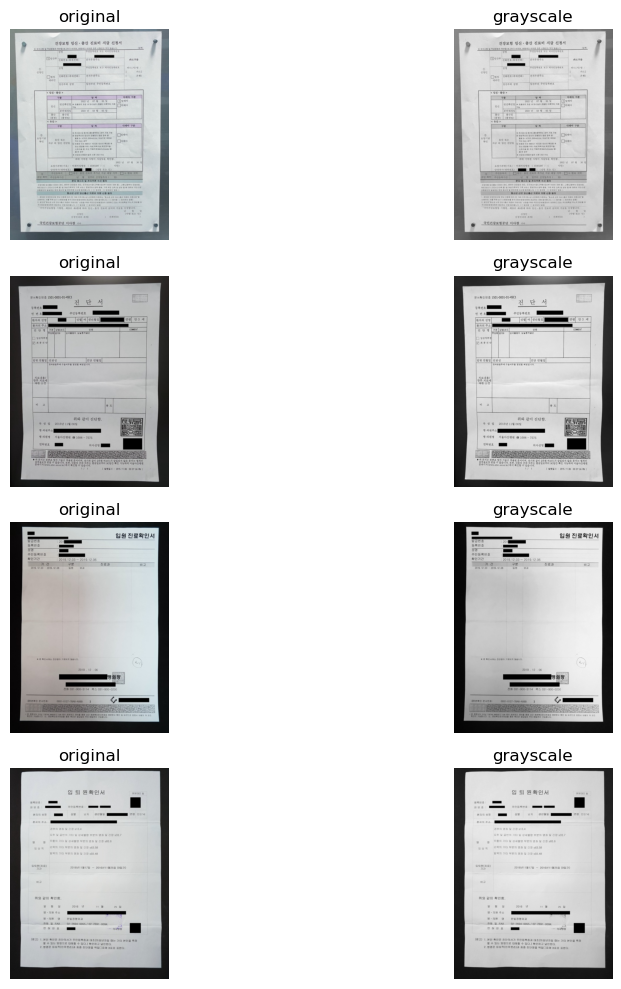

In [11]:
sample_names = train_df[image_col].sample(4, random_state=42).tolist()

plt.figure(figsize=(12, 10))

for i, image_name in enumerate(sample_names):
    image_path = Path(cfg.paths.train_image_dir) / image_name

    raw_image = cv2.imread(str(image_path))
    if raw_image is None:
        continue

    image_bgr = cast(np.ndarray, raw_image)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    plt.subplot(4, 2, 2 * i + 1)
    plt.imshow(image_rgb)
    plt.title("original")
    plt.axis("off")

    plt.subplot(4, 2, 2 * i + 2)
    plt.imshow(gray, cmap="gray")
    plt.title("grayscale")
    plt.axis("off")

plt.tight_layout()
plt.show()